In [1]:
pip install wordcloud monpa tqdm

Note: you may need to restart the kernel to use updated packages.


In [1]:
%%writefile pipeline_worker.py
import pandas as pd
import re
import numpy as np

# ==========================================
# 1. 類別清洗
# ==========================================
def clean_category(cat):
    if pd.isna(cat): return "其他"
    c = str(cat).lower().strip()
    if any(x in c for x in ['politic', '政治', 'vote', '選舉', '立委', '政黨']): return '政治'
    if any(x in c for x in ['social', 'society', '社會', 'local', 'crime', '刑案']): return '社會'
    if any(x in c for x in ['life', 'style', 'living', '生活', 'health', '健康', 'food', '美食', 'travel', '旅遊', '氣象']): return '生活'
    if any(x in c for x in ['ent', 'star', 'celebrity', 'movie', 'music', '娛樂', '影劇', '明星']): return '娛樂'
    if any(x in c for x in ['sport', 'nba', 'mlb', 'gym', '體育', '運動', '棒球', '籃球']): return '體育'
    if any(x in c for x in ['global', 'world', 'intl', 'china', 'us', '國際', '兩岸', '全球']): return '國際'
    if any(x in c for x in ['financ', 'money', 'business', 'stock', 'market', '財經', '經濟', '股市', '房產']): return '財經'
    if any(x in c for x in ['tech', '3c', 'science', 'mobile', 'app', 'ai', '科技', '科學', '電玩']): return '科技'
    if any(x in c for x in ['news', 'focus', 'latest', '即時', '焦點', '快訊']): return '即時'
    return "其他"

# ==========================================
# 2. 文字清洗
# ==========================================
GARBAGE_PATTERNS = [
    r'👉.*', r'更多新聞：.*', r'更多新聞:.*', r'延伸閱讀：.*', r'【延伸閱讀】.*',
    r'更多鏡週刊報導', r'看更多.*', r'→.*', r'外稿 #.*', r'點我下載.*?APP', 
    r'加入.*?LINE好友', r'http\S+', r'<.*?>'
]

def clean_text_strict(text):
    if pd.isna(text): return ""
    text = str(text)
    for p in GARBAGE_PATTERNS:
        text = re.sub(p, '', text, flags=re.DOTALL | re.IGNORECASE)
    return re.sub(r'\s+', ' ', text).strip()

def clean_title_strict(text):
    if pd.isna(text): return ""
    text = str(text)
    text = re.sub(r'[│|-]\s*TVBS.*', '', text)
    text = re.sub(r'[│|-]\s*聯合新聞網.*', '', text)
    text = re.sub(r'[│|-]\s*ETtoday.*', '', text)
    return text.strip()

# ==========================================
# 3. 特徵提取 (關鍵3寶)
# ==========================================
def extract_viral_features(row):
    title = str(row['title_clean'])
    # 1. 標題長度
    title_len = len(title) if len(title) > 0 else 0
    # 2. 情緒標點計數
    punct_count = title.count('!') + title.count('！') + title.count('?') + title.count('？')
    # 3. 是否含數字
    has_digit = 1 if re.search(r'\d', title) else 0
    
    return pd.Series([title_len, punct_count, has_digit], 
                     index=['title_len', 'punct_count', 'has_digit'])

def worker_process_chunk(df_chunk):
    """Worker: 清洗 + 特徵 + 斷詞 (回傳 List)"""
    try:
        import monpa
    except ImportError:
        pass

    # 清洗
    df_chunk['category_clean'] = df_chunk['category'].apply(clean_category)
    df_chunk['title_clean'] = df_chunk['title'].apply(clean_title_strict)
    df_chunk['content_clean'] = df_chunk['content'].apply(clean_text_strict)
    
    # 過濾
    df_chunk = df_chunk.dropna(subset=['title_clean', 'content_clean', 'label'])
    df_chunk = df_chunk[df_chunk['content_clean'].str.len() > 30]
    df_chunk['label'] = pd.to_numeric(df_chunk['label'], errors='coerce').fillna(0).astype(int)
    
    # 提取特徵
    feats = df_chunk.apply(extract_viral_features, axis=1)
    df_chunk = pd.concat([df_chunk, feats], axis=1)
    
    # 斷詞 (轉為 List)
    tokens_list = []
    for text in df_chunk['title_clean']:
        try:
            words = monpa.cut(str(text))
            valid_words = [w for w in words if len(w) > 1 and w not in ['新聞', '報導', '表示', '曝光']]
            # 這裡改回 append(valid_words) 也就是列表
            tokens_list.append(valid_words)
        except:
            tokens_list.append([])
    
    df_chunk['tokens'] = tokens_list
    
    # 回傳 CSV 需要的欄位
    keep_cols = [
        'label', 'category_clean', 'title_clean', 'content_clean', 
        'title_len', 'punct_count', 'has_digit', 'tokens'
    ]
    final_cols = [c for c in keep_cols if c in df_chunk.columns]
    
    return df_chunk[final_cols]

Overwriting pipeline_worker.py


🚀 [Step 1] 啟動前處理 (Clean CSV Only)...
   正在使用 12 核心進行清洗與運算...


/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


+---------------------------------------------------------------------+
  Welcome to MONPA: Multi-Objective NER POS Annotator for Chinese
+---------------------------------------------------------------------+
已找到 model檔。Found model file.
+---------------------------------------------------------------------+
  Welcome to MONPA: Multi-Objective NER POS Annotator for Chinese
+---------------------------------------------------------------------+
已找到 model檔。Found model file.
+---------------------------------------------------------------------+
  Welcome to MONPA: Multi-Objective NER POS Annotator for Chinese
+---------------------------------------------------------------------+
已找到 model檔。Found model file.
+---------------------------------------------------------------------+
  Welcome to MONPA: Multi-Objective NER POS Annotator for Chinese
+---------------------------------------------------------------------+
已找到 model檔。Found model file.
+-------------------------------------------

/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_27590/3245435823.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='viridis')


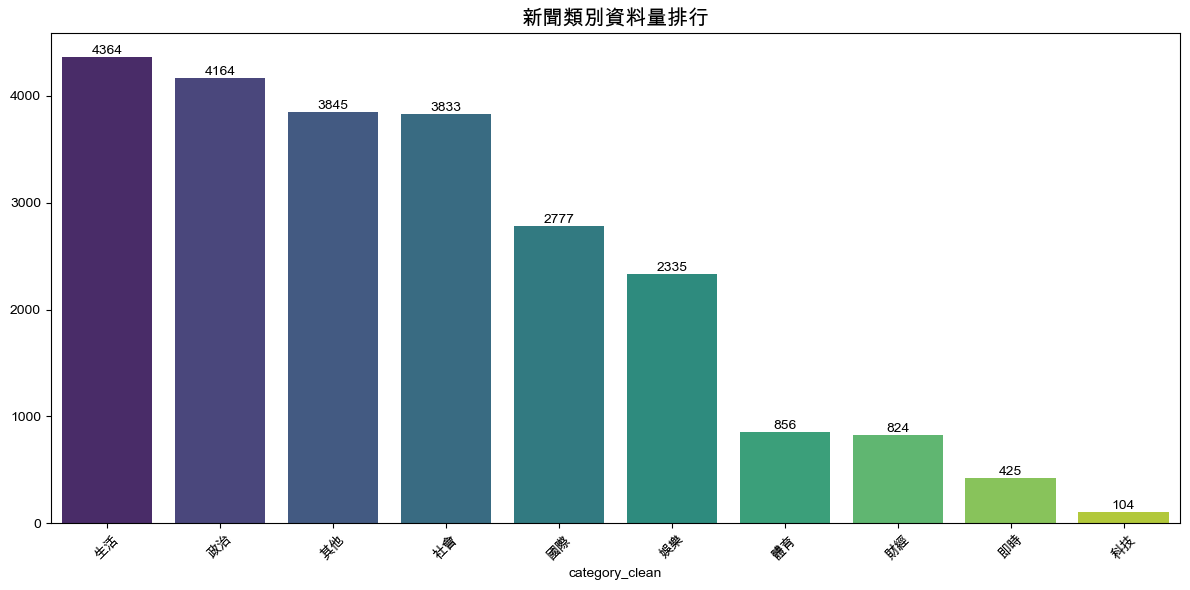

/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_27590/3245435823.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_final, palette=['gray', 'red'])


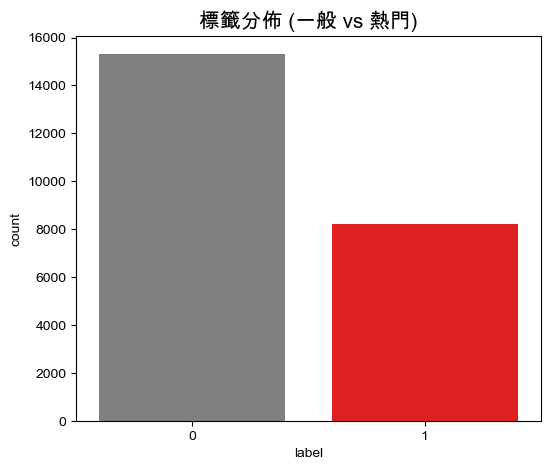

/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_27590/3245435823.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='punct_count', data=df_final, palette=['gray', 'red'], ax=ax[0])
/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_27590/3245435823.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='title_len', data=df_final, palette=['gray', 'red'], ax=ax[1])


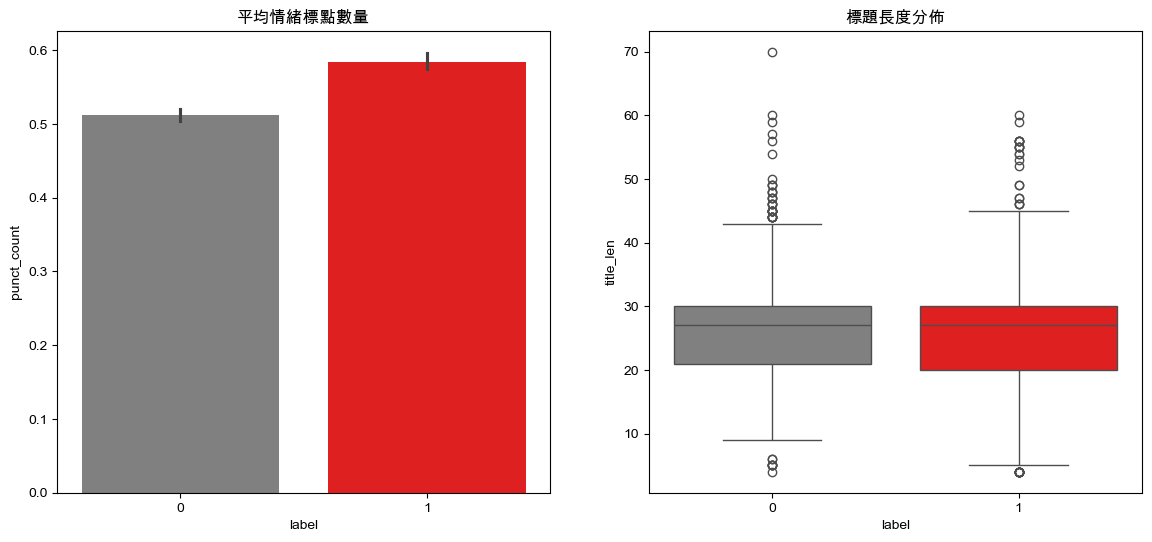

   -> 正在生成文字雲 (L0 & L1)...


/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_27590/3245435823.py:104: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial Unicode MS.
  plt.savefig('eda_wordcloud_L1.png', dpi=300)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)


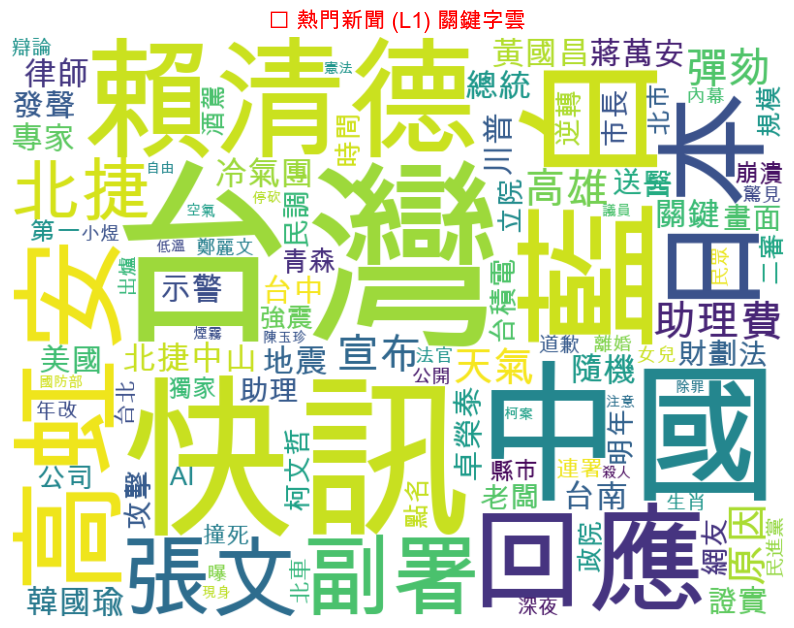

/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_27590/3245435823.py:117: UserWarning: Glyph 129482 (\N{ICE CUBE}) missing from font(s) Arial Unicode MS.
  plt.savefig('eda_wordcloud_L0.png', dpi=300)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129482 (\N{ICE CUBE}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)


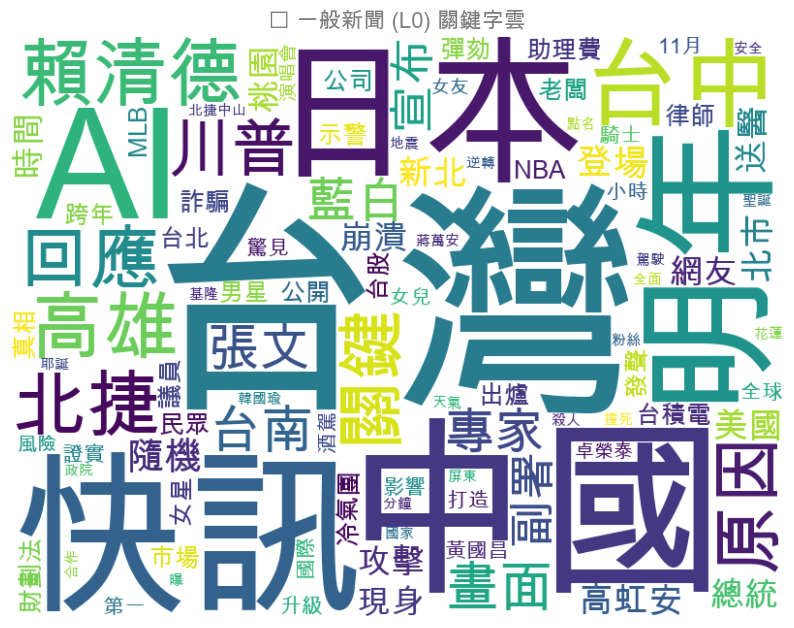


💾 正在儲存 CSV: News_Data_cleaned.csv
   -> 已移除 tokens 欄位 (僅保留清洗後文本與特徵)
✅ 完成！檔案已儲存：News_Data_cleaned.csv
   欄位包含: label, category_clean, title_clean, content_clean, title_len, punct_count, has_digit


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import platform
from multiprocessing import Pool, cpu_count
from wordcloud import WordCloud

# 匯入 Worker
try:
    from pipeline_worker import worker_process_chunk
except ImportError:
    print("❌ 錯誤：找不到 pipeline_worker.py")
    exit()

# 設定
INPUT_FILE = 'News_Data.csv'
OUTPUT_CSV = 'News_Data_cleaned.csv' # 最終輸出檔
NUM_CORES = 12

# 字型設定
system_name = platform.system()
FONT_PATH = None
if system_name == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC', 'PingFang TC']
    possible_fonts = ['/System/Library/Fonts/PingFang.ttc', '/Library/Fonts/Arial Unicode.ttf']
    for f in possible_fonts:
        if os.path.exists(f): FONT_PATH = f; break
else:
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
    FONT_PATH = 'C:\\Windows\\Fonts\\msjh.ttc'
plt.rcParams['axes.unicode_minus'] = False

if __name__ == '__main__':
    print(f"🚀 [Step 1] 啟動前處理 (Clean CSV Only)...")
    start_time = time.time()
    
    # 1. 讀取
    try: df = pd.read_csv(INPUT_FILE)
    except: df = pd.read_csv(INPUT_FILE, encoding='utf-8-sig')
    
    # 2. 平行處理
    print(f"   正在使用 {NUM_CORES} 核心進行清洗與運算...")
    df_split = np.array_split(df, NUM_CORES)
    with Pool(processes=NUM_CORES) as pool:
        results = pool.map(worker_process_chunk, df_split)
    
    df_final = pd.concat(results, axis=0).reset_index(drop=True)
    print(f"   處理完成，有效資料: {len(df_final)} 筆")
    
    # ==========================================
    # 📊 EDA 圖表
    # ==========================================
    print("\n📊 正在生成分析圖表...")
    
    # (1) 新聞類別排行
    plt.figure(figsize=(12, 6))
    cat_counts = df_final['category_clean'].value_counts()
    sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='viridis')
    plt.title('新聞類別資料量排行', fontsize=15)
    plt.xticks(rotation=45)
    for i, v in enumerate(cat_counts.values):
        plt.text(i, v, str(v), ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig('eda_category_rank.png')
    plt.show()
    
    # (2) 標籤分佈
    plt.figure(figsize=(6, 5))
    sns.countplot(x='label', data=df_final, palette=['gray', 'red'])
    plt.title('標籤分佈 (一般 vs 熱門)', fontsize=15)
    plt.savefig('eda_label_dist.png')
    plt.show()

    # (3) 特徵比較
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    sns.barplot(x='label', y='punct_count', data=df_final, palette=['gray', 'red'], ax=ax[0])
    ax[0].set_title('平均情緒標點數量')
    sns.boxplot(x='label', y='title_len', data=df_final, palette=['gray', 'red'], ax=ax[1])
    ax[1].set_title('標題長度分佈')
    plt.savefig('eda_features_compare.png')
    plt.show()

    # (4) 文字雲
    print("   -> 正在生成文字雲 (L0 & L1)...")
    wc_cfg = {
        'font_path': FONT_PATH, 'width': 800, 'height': 600, 
        'background_color': 'white', 'max_words': 100, 'collocations': False
    }
    
    try:
        # A. 熱門新聞 (L1)
        l1_rows = df_final[df_final['label']==1]['tokens']
        l1_text = " ".join([" ".join(tokens) for tokens in l1_rows if len(tokens) > 0])
        
        if len(l1_text) > 0:
            wc_l1 = WordCloud(**wc_cfg).generate(l1_text)
            plt.figure(figsize=(10, 8))
            plt.imshow(wc_l1, interpolation="bilinear")
            plt.title("🔥 熱門新聞 (L1) 關鍵字雲", fontsize=16, color='red')
            plt.axis('off')
            plt.savefig('eda_wordcloud_L1.png', dpi=300)
            plt.show()
        
        # B. 一般新聞 (L0)
        l0_rows = df_final[df_final['label']==0]['tokens']
        l0_text = " ".join([" ".join(tokens) for tokens in l0_rows if len(tokens) > 0])
        
        if len(l0_text) > 0:
            wc_l0 = WordCloud(**wc_cfg).generate(l0_text)
            plt.figure(figsize=(10, 8))
            plt.imshow(wc_l0, interpolation="bilinear")
            plt.title("🧊 一般新聞 (L0) 關鍵字雲", fontsize=16, color='gray')
            plt.axis('off')
            plt.savefig('eda_wordcloud_L0.png', dpi=300)
            plt.show()
            
    except Exception as e:
        print(f"⚠️ 文字雲生成失敗: {e}")

    # ==========================================
    # 💾 儲存 CSV (移除 tokens)
    # ==========================================
    print(f"\n💾 正在儲存 CSV: {OUTPUT_CSV}")
    
    # 🔥 關鍵修正：這裡把 tokens 欄位丟掉
    if 'tokens' in df_final.columns:
        df_final.drop(columns=['tokens'], inplace=True)
        print("   -> 已移除 tokens 欄位 (僅保留清洗後文本與特徵)")
    
    df_final.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
    
    print(f"✅ 完成！檔案已儲存：{OUTPUT_CSV}")
    print(f"   欄位包含: label, category_clean, title_clean, content_clean, title_len, punct_count, has_digit")